In [1]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
img = cv2.imread('./test_image/louis.jpg')
img.shape

(450, 450, 3)

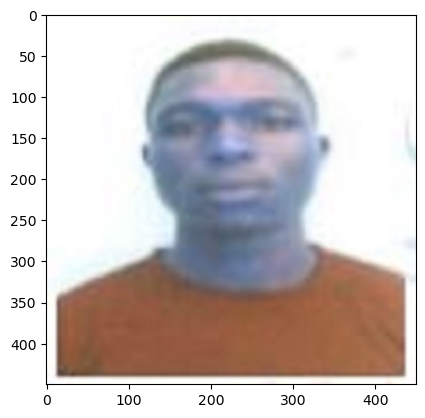

In [3]:
plt.imshow(img)

In [4]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(450, 450)

In [5]:
gray

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [251, 251, 251, ..., 252, 252, 252],
       [251, 251, 251, ..., 253, 253, 253],
       [251, 251, 251, ..., 253, 253, 253]], dtype=uint8)

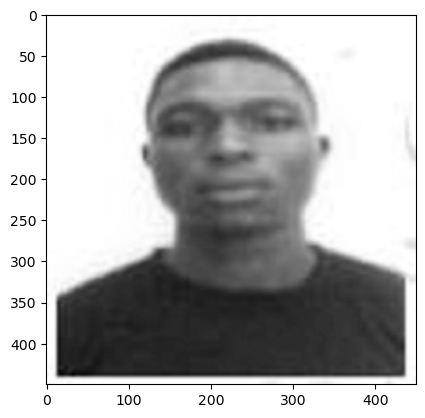

In [6]:
plt.imshow(gray,cmap='gray')

In [7]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray,1.3,5)
faces

array([[114,  46, 218, 218]])

In [8]:
(x,y,w,h) = faces[0]
x,y,w,h

(114, 46, 218, 218)

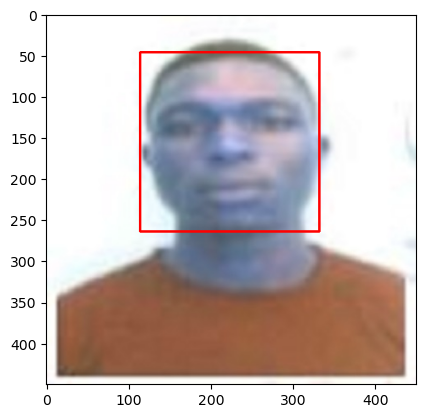

In [9]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

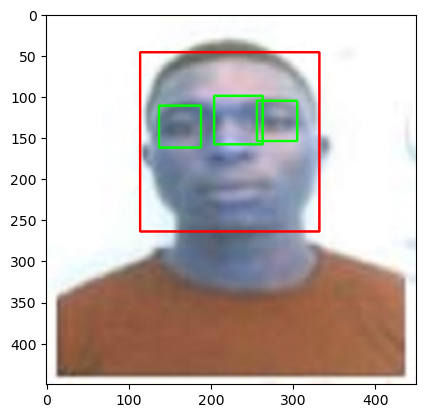

In [10]:
cv2.destroyAllWindows()
for(x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        
plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

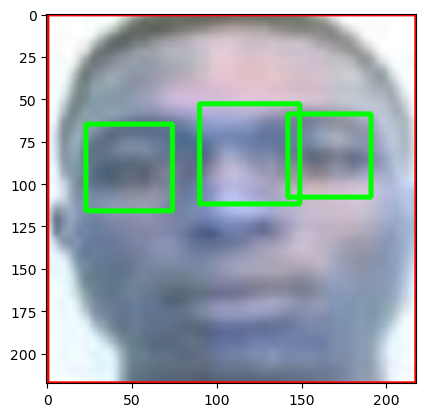

In [11]:
%matplotlib inline
plt.imshow(roi_color,cmap='gray')

In [12]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray,1.3,5)
    for (x,y,w,h) in faces:
        face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = face_img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >=2:
            return roi_color

cropped_image = get_cropped_image_if_2_eyes('./test_image/louis.jpg')
plt.imshow(cropped_image)

In [13]:
path_to_data = "./dataset"
path_to_cr_data = "./dataset/cropped/"

In [14]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [15]:
img_dirs

['./dataset\\cropped', './dataset\\faith_pam', './dataset\\louis_pam']

In [16]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [17]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    celebrity_name = img_dir.split('\\')[-1]
    folder_path = img_dir.split('\\')[0]
    print(folder_path+ '/'+celebrity_name)
    print(celebrity_name)

./dataset/cropped
cropped
./dataset/faith_pam
faith_pam
./dataset/louis_pam
louis_pam


In [18]:
cropped_image_dirs = []
celebrity_file_names_dict = {'faith_pam':[],
                            'louis_pam':[]}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('\\')[-1]
    folder_path = img_dir.split('\\')[0]
    img_dir = folder_path+ '/'+celebrity_name
    print(celebrity_name)
    
    for entry in os.scandir(img_dir):
        v = entry.path
        print(v)
        a = v.split("\\")
        b = a[0]
        path = a[0]+ '/'+a[1]
        
        roi_color = get_cropped_image_if_2_eyes(path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            print(cropped_folder)
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            #cropped_file_name = celebrity_name + str(count) + ".png"
            #cropped_file_path = cropped_folder + "/" + cropped_file_name
            cropped_file_path = cropped_folder + "/" + a[1]
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count +=1

cropped
faith_pam
./dataset/faith_pam\image2.jpg
./dataset/cropped/faith_pam
Generating cropped images in folder:  ./dataset/cropped/faith_pam
./dataset/faith_pam\MNJ.jpg
./dataset/cropped/faith_pam
./dataset/faith_pam\NJUY.jpg
./dataset/cropped/faith_pam
./dataset/faith_pam\ois.jpg
./dataset/faith_pam\one.jpg
./dataset/faith_pam\towe.jpg
./dataset/cropped/faith_pam
louis_pam
./dataset/louis_pam\ejhw.JPG
./dataset/louis_pam\jbn.JPG
./dataset/cropped/louis_pam
Generating cropped images in folder:  ./dataset/cropped/louis_pam
./dataset/louis_pam\Passport_Photo.JPG


In [19]:
import numpy as np
import pywt
import cv2

def w2d(img, mode='haar', level=1):
    imArray = img
    #datatype conversions
    #convert to grayscale
    imArray / 255;
    #imArray = imArray / 255;
    # compute coefficients
    coeffs = pywt.wavedec2(imArray,mode,level=level)
    
    #process coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0;
    
    # reconstruction
    imArray_H= pywt.waverec2(coeffs_H,mode);
    #imArray_H = np.uint8(imArray_H)
    
    return imArray_H

C:\Users\TOSHIBA\anaconda3\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


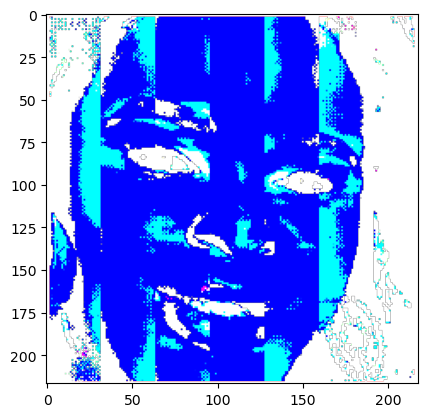

In [20]:
cropped_image = get_cropped_image_if_2_eyes('./test_image/mnj.jpg')
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har,cmap='gray')

In [21]:
celebrity_file_names_dict

{'faith_pam': ['./dataset/cropped/faith_pam/image2.jpg',
  './dataset/cropped/faith_pam/MNJ.jpg',
  './dataset/cropped/faith_pam/NJUY.jpg',
  './dataset/cropped/faith_pam/towe.jpg'],
 'louis_pam': ['./dataset/cropped/louis_pam/jbn.JPG']}

In [22]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'faith_pam': 0, 'louis_pam': 1}

In [23]:
x = []
y = []
for celebrity_name,training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scaled_raw_img = cv2.resize(img,(32,32))
        img_har = w2d(img,'db1',5)
        scaled_img_har = cv2.resize(img_har,(32,32))
        combine_img = np.vstack((scaled_raw_img.reshape(32*32*3,1),scaled_img_har.reshape(32*32*4,1)))
        x.append(combine_img)
        y.append(class_dict[celebrity_name])

In [24]:
32*32*3 + 32*32

4096

In [25]:
len(x[0])

7168

In [26]:
x = np.array(x).reshape(len(x),7168).astype(float)

In [27]:
x.shape

(5, 7168)

In [28]:
x[0]

array([237.        , 147.        , 153.        , ...,  54.74401855,
        57.75964355,  57.75964355])

# WE ARE GOING TO START TRAINING OUR MODEL NOW.

In [29]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [30]:
y[:-3]

[0, 0]

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=0)
pipe = Pipeline([('scaler',StandardScaler()),('svc',SVC(kernel = 'rbf', C=10))])
pipe.fit(x_train,y_train)
pipe.score(x_test,y_test)

1.0

In [32]:
print(classification_report(y_test, pipe.predict(x_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



# USING GRIDSEARCH

In [33]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [34]:
model_params = {
        'svm':{
        'model': SVC(),
        'params': {
                    #'svc__c': [1,10,100,1000],
                   # 'svc__kernel': ['rbf','linear']
                   }
    },
    'random_forest':{
        'model': RandomForestClassifier(),
        'params': {
                   'randomforestclassifier__n_estimators': [1,5,10]
                   }
    },
    'logistic_regression':{
        'model': LogisticRegression(solver='liblinear'),
        'params': {
                   'logisticregression__C': [1,5,10]
                   }   
    }
}

In [35]:
for algo, mp in model_params.items():
    print(mp['params'])

{}
{'randomforestclassifier__n_estimators': [1, 5, 10]}
{'logisticregression__C': [1, 5, 10]}


In [36]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(),mp['model'])
    clf = GridSearchCV(pipe,mp['params'],cv=2, return_train_score=False,)
    clf.fit(x_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

C:\Users\TOSHIBA\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\TOSHIBA\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
1 fits failed out of a total of 2.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\TOSHIBA\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\TOSHIBA\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_metho

,model,best_score,best_params
0,svm,NaN,{}
1,random_forest,0.75,{'randomforestclassifier__n_estimators': 1}
2,logistic_regression,NaN,{'logisticregression__C': 1}


In [37]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=1))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, solver='liblinear'))])}

In [38]:
best_estimators['svm']

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [39]:
best_estimators['svm'].score(x_test,y_test)

1.0

In [40]:
best_estimators['random_forest'].score(x_test,y_test)

0.5

In [41]:
best_estimators['logistic_regression'].score(x_test,y_test)

0.5

In [42]:
best_clf = best_estimators['random_forest']

In [43]:
class_dict

{'faith_pam': 0, 'louis_pam': 1}

# SAVE THE TRAINED MODEL

In [44]:
!pip install joblib
import joblib
# save the model as a pickle in a file
joblib.dump(best_clf,'saved_model.pkl')

['saved_model.pkl']

# SAVE CLASS DICTIONARY

In [45]:
import json
with open('class_dictionary.json','w') as f:
    f.write(json.dumps(class_dict))